In [1]:
import numpy as np
import pandas as pd
import ast
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')
movies = movies.merge(credits,on='title')
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]
movies.head()
movies.isnull().sum()
movies.dropna(inplace=True)
movies.duplicated().sum()
movies.iloc[0].genres
def convert(obj):
  L = []
  if isinstance(obj, str):
    for i in ast.literal_eval(obj):
      L.append(i['name'])
  return L

movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)
movies.head()

def convert3(obj):
  L=[]
  counter=0
  for i in ast.literal_eval(obj):
    if counter!=3:
      L.append(i['name'])
      counter+=1
    else:
      break
  return L
movies['cast']=movies['cast'].apply(convert3)
def fetch_director(obj):
  L=[]
  for i in ast.literal_eval(obj):
    if i['job']=='Director':
      L.append(i['name'])
      break
  return L
movies['crew']=movies['crew'].apply(fetch_director)
movies['overview']=movies['overview'].apply(lambda x:x.split())
movies['genres']=movies['genres'].apply(lambda x:[i.replace(" ","") for i in x])
movies['keywords']=movies['keywords'].apply(lambda x:[i.replace(" ","") for i in x])
movies['cast']=movies['cast'].apply(lambda x:[i.replace(" ","") for i in x])
movies['crew']=movies['crew'].apply(lambda x:[i.replace(" ","") for i in x])
movies.head()
movies['tags']=movies['overview']+movies['genres']+movies['keywords']+movies['cast']+movies['crew']
movies.head()
new_df=movies[['movie_id','title','tags']]
new_df['tags']=new_df['tags'].apply(lambda x:" ".join(x))
new_df['tags']=new_df['tags'].apply(lambda x:x.lower())
new_df.head()
new_df['tags'][0]
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=5000,stop_words='english')
vectors=cv.fit_transform(new_df['tags']).toarray()
vectors
cv.get_feature_names_out()
import nltk
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
def stem(text):
  y=[]
  for i in text.split():
    y.append(ps.stem(i))
  return " ".join(y)
new_df['tags']=new_df['tags'].apply(stem)
new_df['tags'][0]
vectors=cv.fit_transform(new_df['tags']).toarray()
cv.get_feature_names_out()
from sklearn.metrics.pairwise import cosine_similarity
similarity=cosine_similarity(vectors)
similarity[0]
def recommend(movie):
  movie_index=new_df[new_df['title']==movie].index[0]
  distances=similarity[movie_index]
  movies_list=sorted(list(enumerate(distances)),reverse=True,key=lambda x:x[1])[1:6]
  for i in movies_list:
    print(new_df.iloc[i[0]].title)
recommend('Avatar')
# movies.head()

<ipython-input-1-0350d5e2c6ba>:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']=new_df['tags'].apply(lambda x:" ".join(x))
<ipython-input-1-0350d5e2c6ba>:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']=new_df['tags'].apply(lambda x:x.lower())
<ipython-input-1-0350d5e2c6ba>:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

Aliens vs Predator: Requiem
Aliens
Falcon Rising
Independence Day
Titan A.E.


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = vectors.shape[1]
encoding_dim = 100
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(vectors, vectors, epochs=50, batch_size=256, shuffle=True)
movie_embeddings = encoder.predict(vectors)
compressed_vectors = encoder.predict(vectors)
print(movie_embeddings.shape)



Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - loss: 0.6599
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.2743
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0660
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0504
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0478
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0475
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0464
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0464
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.0453
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0448
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0446
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0440
Epoch 13/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0432
Epoch 14/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0432
Epoch 15/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0426

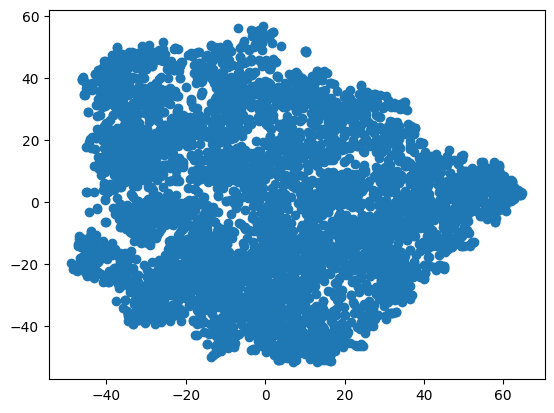

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
tsne = TSNE(n_components=2)
movie_embeddings_2d = tsne.fit_transform(movie_embeddings)
plt.scatter(movie_embeddings_2d[:, 0], movie_embeddings_2d[:, 1])
plt.show()


In [4]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(movie_embeddings)

def recommend_autoencoder():
    print("Welcome to the Movie Recommendation System!")
    print("Enter a movie title to get recommendations. Type 'exit' to quit.")

    while True:
        movie = input("\nEnter a movie title: ").strip()

        if movie.lower() == 'exit':
            print("Thank you for using the Movie Recommendation System. Goodbye!")
            break

        if movie not in new_df['title'].values:
            print(f"Movie '{movie}' not found in the dataset. Please try another title or check for typos.")
            print("Here are some example movies you can try:")
            print(new_df['title'].sample(5).to_string(index=False))
            continue

        movie_index = new_df[new_df['title'] == movie].index[0]
        distances = similarity_matrix[movie_index]
        movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

        print(f"\nMovies similar to '{movie}':")
        for i, (index, _) in enumerate(movie_list):
            print(f"{i + 1}. {new_df.iloc[index].title}")

recommend_autoencoder()




Welcome to the Movie Recommendation System!
Enter a movie title to get recommendations. Type 'exit' to quit.

Enter a movie title: Avatar

Movies similar to 'Avatar':
1. Ender's Game
2. The Host
3. Jupiter Ascending
4. Guardians of the Galaxy
5. 2001: A Space Odyssey

Enter a movie title: exit
Thank you for using the Movie Recommendation System. Goodbye!


In [6]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.6 MB/s eta 0:00:00


In [7]:
import torch
from torch_geometric.nn import GCNConv
from sklearn.metrics.pairwise import cosine_similarity

movie_node_features = torch.tensor(movie_embeddings, dtype=torch.float32)

edge_index = torch.tensor([

    [0, 1], [1, 2], [2, 0], [0, 3], [1, 4], [2, 5]
], dtype=torch.long).t().contiguous()

class GNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x

in_channels = movie_node_features.shape[1]
hidden_channels = 128
out_channels = 64
model = GNN(in_channels, hidden_channels, out_channels)
movie_embeddings_gnn = model(movie_node_features, edge_index)

similarity_matrix_gnn = cosine_similarity(movie_embeddings_gnn.detach().numpy())

def recommend_gnn():
    while True:
        movie = input("\nEnter a movie title (or type 'exit' to quit): ").strip()
        if movie.lower() == 'exit':
            print("Exiting the recommendation system.")
            break

        if movie not in new_df['title'].values:
            print(f"Movie '{movie}' not found in the dataset.")
            continue

        movie_index = new_df[new_df['title'] == movie].index[0]
        distances = similarity_matrix_gnn[movie_index]
        movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

        print(f"\nMovies similar to '{movie}':")
        for i, (index, _) in enumerate(movie_list):
            print(f"{i + 1}. {new_df.iloc[index].title}")

recommend_gnn()



Enter a movie title (or type 'exit' to quit): Avatar

Movies similar to 'Avatar':
1. Pirates of the Caribbean: At World's End
2. The Dark Knight Rises
3. Spectre
4. Goldfinger
5. Spider-Man 3

Enter a movie title (or type 'exit' to quit): exit
Exiting the recommendation system.


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')
movies = movies.merge(credits, on='title')
movies['overview'] = movies['overview'].fillna('')  # Fill NaN values

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['overview'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def recommend_tfidf(movie_title, num_recommendations=5):
    if movie_title not in movies['title'].values:
        print(f"Movie '{movie_title}' not found.")
        return

    idx = movies.index[movies['title'] == movie_title][0]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:num_recommendations + 1]

    movie_indices = [i[0] for i in sim_scores]

    recommended_titles = movies['title'].iloc[movie_indices].values
    return recommended_titles

def main():
    print("Welcome to the Movie Recommendation System!")
    print("Enter a movie title to get recommendations. Type 'exit' to quit.")

    while True:
        movie_title = input("\nEnter a movie title: ").strip()
        if movie_title.lower() == 'exit':
            print("Thank you for using the Movie Recommendation System. Goodbye!")
            break

        recommended_movies = recommend_tfidf(movie_title)
        if recommended_movies is not None:
            print("Recommended movies for you:")
            for movie in recommended_movies:
                print(movie)

main()


Welcome to the Movie Recommendation System!
Enter a movie title to get recommendations. Type 'exit' to quit.
Recommended movies for you:
Apollo 18
The American
The Matrix
The Inhabited Island
Tears of the Sun


<Figure size 800x400 with 0 Axes>

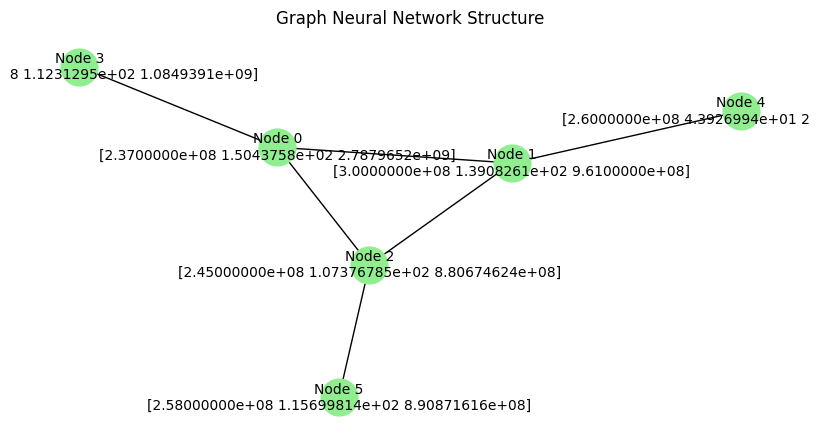


Enter a movie title: exit
Exiting the recommendation system.


In [ ]:
import torch
from torch_geometric.nn import GCNConv
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

movie_features = movies[['budget', 'popularity', 'revenue']].fillna(0)

movie_node_features = torch.tensor(movie_features.values, dtype=torch.float32)

edge_index = torch.tensor([
    [0, 1], [1, 2], [2, 0], [0, 3], [1, 4], [2, 5]
], dtype=torch.long).t().contiguous()

class GNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x

in_channels = movie_node_features.shape[1]
hidden_channels = 128
out_channels = 64
model = GNN(in_channels, hidden_channels, out_channels)
movie_embeddings_gnn = model(movie_node_features, edge_index)
similarity_matrix_gnn = cosine_similarity(movie_embeddings_gnn.detach().numpy())
def plot_graph(edge_index, node_features):
    G = nx.Graph()
    for i in range(edge_index.size(1)):
        G.add_edge(edge_index[0][i].item(), edge_index[1][i].item())

    labels = {node: f'Node {node}\n{node_features[node].numpy()}' for node in G.nodes()}

    pos = nx.spring_layout(G)
    plt.figure(figsize=(8, 4))
    nx.draw(G, pos, with_labels=True, labels=labels, node_size=700, node_color='lightgreen', font_size=10)
    plt.title('Graph Neural Network Structure')
    plt.axis('off')
    plt.show()


plt.figure(figsize=(8, 4))
plot_graph(edge_index, movie_node_features)

def recommend_gnn():
    while True:
        movie = input("\nEnter a movie title: ").strip()
        if movie.lower() == 'exit':
            print("Exiting the recommendation system.")
            break

        if movie not in movies['title'].values:
            print(f"Movie '{movie}' not found in the dataset.")
            continue

        movie_index = movies[movies['title'] == movie].index[0]
        distances = similarity_matrix_gnn[movie_index]
        movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

        print(f"\nMovies similar to '{movie}':")
        for i, (index, _) in enumerate(movie_list):
            print(f"{i + 1}. {movies.iloc[index].title}")

recommend_gnn()


In [ ]:
from sklearn.metrics import precision_score, recall_score

ground_truth = [1, 50, 100, 200, 300]

recommended_movies = [0, 2, 5, 50, 100]
y_true = [1 if i in ground_truth else 0 for i in range(len(new_df))]
y_pred = [1 if i in recommended_movies else 0 for i in range(len(new_df))]

precision_cb = precision_score(y_true, y_pred)
recall_cb = recall_score(y_true, y_pred)

print(f'Precision (Content-Based): {precision_cb}')
print(f'Recall (Content-Based): {recall_cb}')


In [ ]:

common_length = min(len(y_true), len(y_pred_gnn))

y_true = y_true[:common_length]
y_pred_gnn = y_pred_gnn[:common_length]

precision_gnn = precision_score(y_true, y_pred_gnn)
recall_gnn = recall_score(y_true, y_pred_gnn)

print(f'Precision (GNN-Based): {precision_gnn}')
print(f'Recall (GNN-Based): {recall_gnn}')




Precision (GNN-Based): 0.6
Recall (GNN-Based): 0.6
